# Tidy3D's inverse-design workflow in BeamZ: a 1 → 3 splitter

## Goal

Recreate the single-simulation workflow from Flexcompute's [Inverse design plugin notebook](https://www.flexcompute.com/tidy3d/examples/notebooks/InverseDesign/) using `beamz.optimization`: define a region, supply a function of monitor data, run Adam, inspect history, and resume from disk. The same function can use electromagnetic adjoint FDTD or full time-step autodiff.

This is a **BeamZ port at coarser resolution**, not a numerical replication of Tidy3D results. Reference: the example library viewed 2026-09-21; client API reviewed at Tidy3D v2.12.0, commit `4cacc2755d5858e0de5a8066ff017f1b9e3ad9f9`.

| Item | Reference / BeamZ port |
|---|---|
| Wavelength, index | Both: 1 µm, core n=2, background n=1 |
| Design / domain | Both: 4 × 4.2 µm / 8 × 6.2 µm |
| Guides | Both: three 0.5 µm output guides, centers −1.4, 0, +1.4 µm |
| Parameters | BeamZ metre units and `(y, x)` arrays; lower-left domain coordinates |
| Grid | Reference automatic grid, target ~16.7 nm; BeamZ uniform 25 nm (previous run: 50 nm) |
| Transform / penalty | Conic+tanh: radius 120 nm, beta 10; erosion/dilation weight 0.8, scale 120 nm |
| Objective | Both: three times a softmin-weighted average of output modal powers |
| Optimizer | Adam, learning rate 0.1, 10 steps then one continuation step |
| Runtime | Reference: 50 / bandwidth = 1.668 ps; BeamZ: 75 / bandwidth = 2.502 ps for adjoint decay |

BeamZ uses its 2D TM convention (Ez, Hx, Hy), CPML thickness 0.6 µm, and its own modal injection, rasterization, and field normalization. The Gaussian bandwidth argument is converted to match the reference envelope convention. Kernels round filter radii up to pixels; the penalty uses a tiny smooth norm near zero. No Tidy3D installation, service, or solver result is used.

The numerical symmetry audit below checks material placement, source injection, modal measurement, fields, and both gradients. BeamZ now averages design-cell values onto staggered Yee supports, uses a centered TM source window, and colocates the monitor basis with its field samples. The adjoint retains every node touched by that interpolation. These changes preserve reflection without constraining optimization. Older optimizer histories use a different numerical objective and cannot be resumed; this notebook starts a fresh run.

This run doubles the spatial resolution in each direction to 25 nm: a 320 × 248 cell domain and 160 × 168 design parameters. It starts a new optimization on the finer grid; it is not a fixed-design mesh-convergence study. The previously executed 50 nm notebook and its artifacts are preserved in `results/topology_examples/`.

## Setup

Use the BeamZ source environment (`uv sync --extra dev`) and its Python kernel. All lengths below are **metres**, frequencies Hz, and times seconds. Use `jax.numpy` in differentiable callbacks. Checkpoints contain arrays and JSON, so restoring requires this optimizer and the objective function rather than unpickling executable code.

In [1]:
from pathlib import Path
import time
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from beamz import (Design, Material, Rectangle, Simulation, ModeSource, ModeMonitor,
                   ModeSpec, GaussianPulse, PML, LIGHT_SPEED)
import beamz.optimization as bi

plt.rcParams.update({"figure.dpi": 120, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})
repo = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/"pyproject.toml").exists())
artifacts = repo / "results" / "topology_examples" / "tidy3d_splitter_25nm"
artifacts.mkdir(parents=True, exist_ok=True)
um = 1e-6
wavelength, dx = 1*um, 0.025*um
frequency = LIGHT_SPEED / wavelength
reference_bandwidth = frequency / 10
# The corrected optimization needs a longer window for adjoint pulse decay.
run_time = 75 / reference_bandwidth
print(f"JAX {jax.__version__}, {jax.default_backend()}, {run_time*1e15:.1f} fs")

JAX 0.9.0, cpu, 2501.7 fs


## Steps

### 1. Define the ordinary BeamZ simulation

The fixed geometry and monitors use BeamZ objects. The design region is added separately by `InverseDesign`. An extra input monitor measures delivered power for the final diagnostic; the optimization objective follows the reference's output-power definition.

In [2]:
background, core = Material(permittivity=1), Material(permittivity=4)
geometry = Design(width=8*um, height=6.2*um, material=background)
geometry += Rectangle(position=(0, 2.85*um), width=2*um, height=0.5*um, material=core)
output_y = np.array([1.7, 3.1, 4.5])*um
for y in output_y:
    geometry += Rectangle(position=(6*um, y-0.25*um), width=2*um, height=0.5*um, material=core)
modes = ModeSpec(num_modes=1, polarization="tm")
source = ModeSource(center=(1*um,3.1*um,0), size=(0,2.12*um,1*um), direction="+",
                    mode_spec=modes,
                    source_time=GaussianPulse(freq0=frequency,
                        fwidth=reference_bandwidth/(2*np.pi), offset=5/(2*np.pi)))
outputs = [ModeMonitor(center=(7*um,float(y),0), size=(0,2.12*um,1*um),
                       freqs=[frequency], mode_spec=modes, name=f"MNT_{i}")
           for i,y in enumerate(output_y)]
incoming = outputs[0].updated_copy(center=(1.5*um,3.1*um,0), name="input")
simulation = Simulation(design=geometry, resolution=dx, run_time=run_time,
                        sources=[source], monitors=[incoming,*outputs], polarization="tm",
                        boundaries=[PML(thickness=0.6*um, formulation="cpml")])

### Inspect the simulation layout

Use BeamZ's `Simulation.plot()` for the geometry, source, monitors, and boundaries. As in the reference, add only a rectangle outlining the design region. The layout's underlying coordinates are metres, with automatically formatted axis labels.

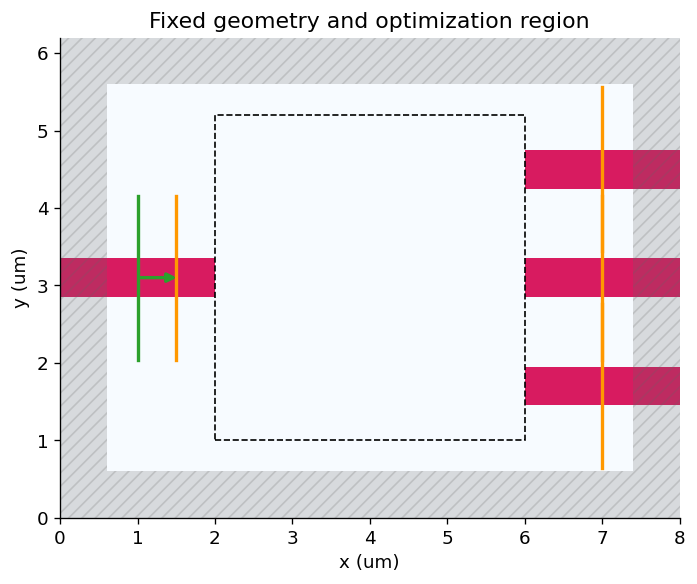

In [3]:
from matplotlib.patches import Rectangle as PlotRectangle

plot_dir = artifacts / "tidy3d_splitter_plots"
plot_dir.mkdir(exist_ok=True)
# Layout axes and annotations use micrometres, as in 3D layout plots.
fig, ax = simulation.plot(figsize=(8,5))
ax.add_patch(PlotRectangle((2,1),4,4.2,fill=False,
                          edgecolor="black",linestyle="--"))
ax.set_title("Fixed geometry and optimization region")
fig.savefig(plot_dir / "01_simulation_layout.png", dpi=180)
plt.show()

### 2. Define the region and transformations

These class names and arguments mirror the Tidy3D workflow. Uniform initialization, filter/projection, and penalty are separate specifications. Changing the derivative method requires only `gradient_backend="autodiff"` or `"adjoint"` on `InverseDesign`.

In [4]:
design_region = bi.TopologyDesignRegion(
    size=(4*um,4.2*um,np.inf), center=(4*um,3.1*um,0),
    eps_bounds=(1,4), pixel_size=dx,
    transformations=[bi.FilterProject(radius=0.120*um, beta=10)],
    penalties=[bi.ErosionDilationPenalty(length_scale=0.120*um, weight=0.8)],
    initialization_spec=bi.UniformInitializationSpec(value=0.5),
)
design = bi.InverseDesign(simulation=simulation, design_region=design_region,
                         output_monitor_names=[m.name for m in simulation.monitors],
                         gradient_backend="adjoint")
params0 = design_region.initial_parameters
print("Parameter shape (y,x):", params0.shape, "| trainable cells:", params0.size)

Parameter shape (y,x): (168, 160) | trainable cells: 26880


### Inspect filtering and the initial full device

The reference mirrors its random array along **physical y** using `np.fliplr` on an `(x,y,z)` array. BeamZ stores `(y,x)`, so the equivalent is `np.flip(..., axis=0)`. We explicitly check symmetry both before and after filtering. This is an illustration, not the optimization's initial state: the reference subsequently resets all parameters to 0.5.

The transformed parameter-array plot is drawn directly with Matplotlib, as in the reference. Full-device permittivity uses BeamZ's `Simulation.plot_eps()`, which reads the actual material raster, including optimized material grids.

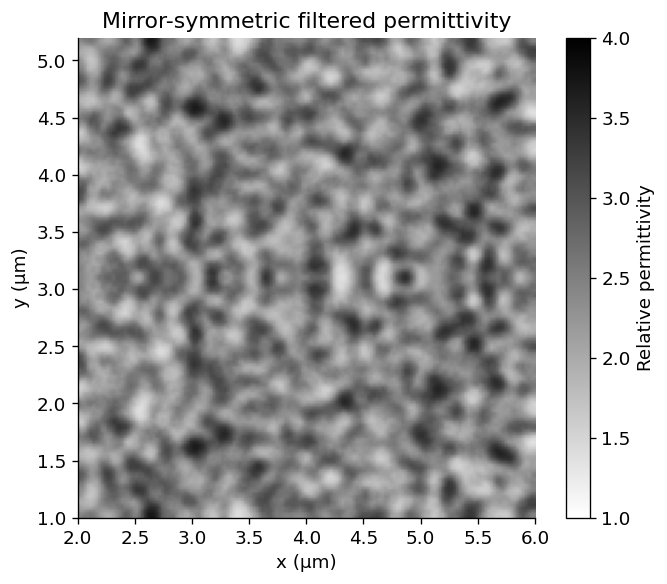

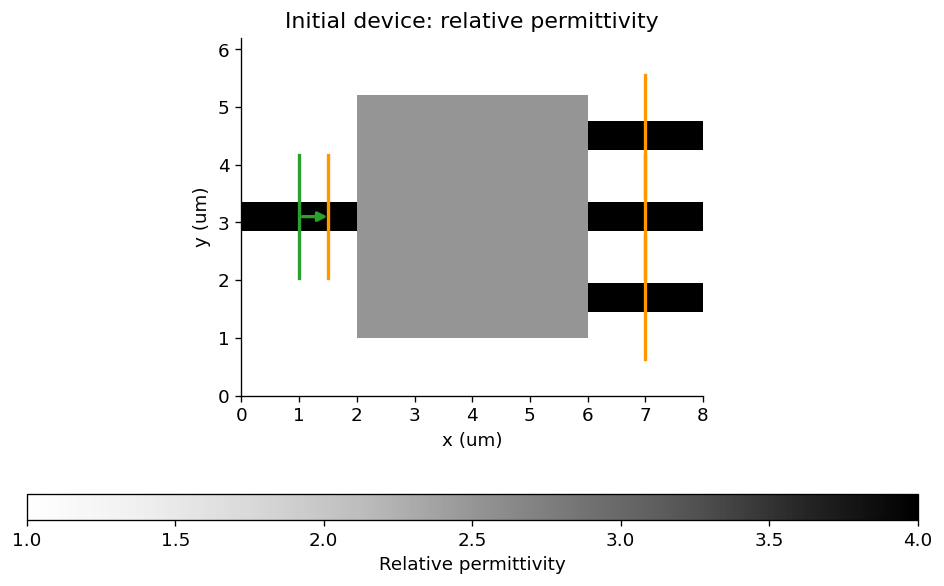

In [5]:
random_params = np.random.default_rng(11).random(design_region.params_shape)
random_params = 0.5 * (random_params + np.flip(random_params, axis=0))
random_eps = np.asarray(design_region.eps_values(random_params))
np.testing.assert_array_equal(random_params, np.flip(random_params, axis=0))
np.testing.assert_allclose(random_eps, np.flip(random_eps, axis=0), rtol=0, atol=2e-6)

# The reference draws this parameter-array diagnostic with Matplotlib too.
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(random_eps, origin="lower", extent=[2,6,1,5.2], cmap="binary", vmin=1,vmax=4)
fig.colorbar(im, ax=ax, label="Relative permittivity")
ax.set(xlabel="x (µm)",ylabel="y (µm)",title="Mirror-symmetric filtered permittivity")
fig.tight_layout()
fig.savefig(plot_dir / "02_filter_projection.png", dpi=180)
plt.show()

initial_simulation = design.to_simulation(params0)
fig, ax = initial_simulation.plot_eps(z=0, figsize=(8,5), vmin=1,vmax=4)
ax.set_title("Initial device: relative permittivity")
fig.savefig(plot_dir / "03_initial_permittivity.png", dpi=180)
plt.show()

### 3. Write the objective from returned monitor data

The callback uses `data[name].amps.sel(...).values`. Complex values remain differentiable, so the interface can also express interference or phase objectives. Here we use the reference's normalized softmin-weighted output power. Penalties are subtracted by `InverseDesign`.

In [6]:
def post_process_fn(data):
    powers = jnp.stack([bi.utils.sum_abs_squared(
        data[m.name].amps.sel(direction="+", mode_index=0).values) for m in outputs])
    weights = jax.nn.softmax(-powers)
    return len(outputs) * jnp.sum(weights * powers)

objective = design.make_objective_fn(post_process_fn)
initial_data = design.to_simulation_data(params0)
initial_score = float(post_process_fn(initial_data))
print(f"Initial post-process score: {initial_score:.6f}")

Initial post-process score: 0.306375


### Inspect the initial electric field

Like the reference, run a separate forward simulation with a planar field monitor and call the native result's `plot_field` method. In BeamZ's 2D TM convention, $|E|^2=|E_z|^2$. This plots the frequency-domain response at λ=1 µm using BeamZ's source normalization; it is not a late-time pulse snapshot, transmitted power, or a cross-solver amplitude comparison. No notebook-defined field renderer or extra amplitude rescaling is used.

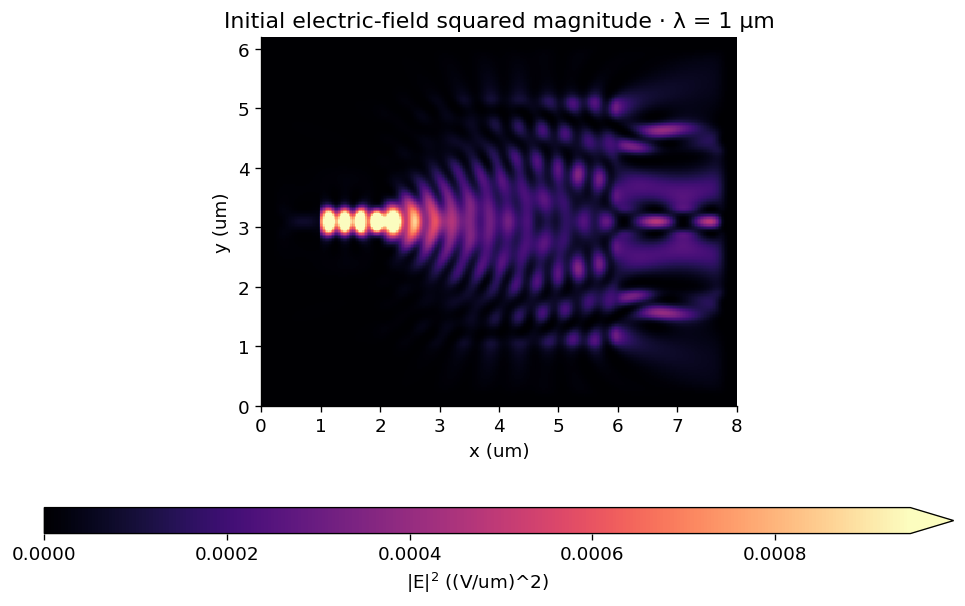

Initial outer modal powers: [0.09136859327554703, 0.09136855602264404]
Initial complex-field mirror mismatch: 0.0000050%


In [7]:
def mirror_error(values):
    values = np.asarray(values)
    return float(np.linalg.norm(values - values[::-1]) / max(np.linalg.norm(values), 1e-30))

from beamz import FieldMonitor

field_monitor = FieldMonitor(center=(4*um,3.1*um,0), size=(8*um,6.2*um,0),
                             freqs=[frequency], fields=("Ez",), name="inspection_fields")
initial_field_data = initial_simulation.updated_copy(
    monitors=[*initial_simulation.monitors, field_monitor]
).run(backend="jax", performance=False)
for monitor in outputs:
    np.testing.assert_allclose(
        initial_field_data.mode(monitor.name).amps.sel(direction="+",mode_index=0).values,
        initial_data[monitor.name].amps.sel(direction="+",mode_index=0).values,
        rtol=5e-5, atol=1e-6)
fig, ax = initial_field_data.plot_field(field_monitor.name, field_name="E", val="abs^2",
                                      frequency=frequency, figsize=(8,5), cmap="magma")
ax.set_title("Initial electric-field squared magnitude · λ = 1 µm")
fig.savefig(plot_dir / "04_initial_field_intensity.png", dpi=180)
plt.show()
initial_ez = initial_field_data[field_monitor.name].get_dft_component("Ez").reshape(
    round(6.2*um/dx), round(8*um/dx))
initial_field_mirror_error = mirror_error(initial_ez)
assert initial_field_mirror_error < 1e-5
outer_powers = [float(bi.utils.sum_abs_squared(bi.utils.get_amps(initial_data, m.name,
    direction="+", mode_index=0))) for m in (outputs[0], outputs[2])]
np.testing.assert_allclose(*outer_powers, rtol=2e-5)
print("Initial outer modal powers:", outer_powers)
print(f"Initial complex-field mirror mismatch: {100*initial_field_mirror_error:.7f}%")


### 4. Verify both derivative alternatives on the same problem

Use seeded, mirror-symmetric noise for a nontrivial gradient check. Both random arrays in this notebook reflect about physical y=3.1 µm. The reference does **not** impose a mirror transformation or solver-symmetry constraint during optimization; it only symmetrizes its random illustration and then starts from uniform parameters. We likewise do not project gradients or Adam updates onto a symmetric subspace.

This runs the full finite-duration autodiff reference once and compares it with the spectral adjoint. The default decay guard applies independently to the forward and adjoint pulse responses.

Reflection mismatch is `||a - flip_y(a)|| / ||a||`. We check the signed gradient itself, not its magnitude. For Ez this reflection has even parity. These are numerical invariance checks, not evidence of mesh convergence or absolute transmission accuracy. The before-fix measurements below were recorded at 50 nm on the uniform initial design during the earlier investigation; the current cells measure the corrected model at 25 nm. These columns differ in both numerical mapping and mesh resolution. The historical audit used 1.668 ps; this fresh optimization uses 2.502 ps because the second update failed the adjoint decay guard at the shorter duration. The guard remains at 1e-4.

A longer simulation window alone did not resolve the residual adjoint excitation. The internal adjoint pulse now uses a smoother three-period Gaussian envelope with an eight-width leading margin, normalized by its measured DFT. This keeps the same frequency-domain source strength and the same decay threshold.

At 25 nm, the adjoint additionally uses the discrete temporal difference of that envelope-modulated carrier to suppress its DC response. Its measured DFT preserves the frequency-domain normalization, and the same 1e-4 guard remains active. The full autodiff comparison below independently checks this implementation.

The finer-grid check also exposed clock drift from repeatedly adding a float32 timestep. BeamZ now derives observation time from the integer step counter and the run origin. The full-gradient check below validates the corrected timing against autodiff; checkpoint identities distinguish this numerical revision.

In [8]:
noise = np.random.default_rng(7).normal(size=params0.shape)
noise = 0.5 * (noise + np.flip(noise, axis=0))
probe = params0 + 0.02*noise
np.testing.assert_array_equal(probe, np.flip(probe, axis=0))
automatic_design = design.updated_copy(gradient_backend="autodiff")
value_ad, grad_ad = jax.value_and_grad(automatic_design.make_objective_fn(post_process_fn))(probe)
value_adj, grad_adj = jax.value_and_grad(objective)(probe)
relative_gradient_error = float(jnp.linalg.norm(grad_adj-grad_ad)/jnp.linalg.norm(grad_ad))
np.testing.assert_allclose(value_adj, value_ad, rtol=2e-5)
print(f"Relative complete-gradient difference: {100*relative_gradient_error:.4f}%")
print("Adjoint diagnostics:", design.gradient_diagnostics)
assert relative_gradient_error < 0.005
for gradient in (grad_ad, grad_adj):
    assert mirror_error(gradient) < 1e-4
_, initial_gradient = jax.value_and_grad(objective)(params0)
initial_gradient_mirror_error = mirror_error(initial_gradient)
assert initial_gradient_mirror_error < 1e-4

# Inspect actual global Yee supports, not the cropped local mode arrays.
program = design._problem.program
source_mirror_errors = {}
for source in program.sources:
    coefficients = np.zeros(program.grid.component_shapes[source.component])
    coefficients[source.index] = np.asarray(source.coeff).squeeze()
    source_mirror_errors[source.component] = mirror_error(coefficients)
assert max(source_mirror_errors.values()) < 1e-7
initial_yee = initial_simulation.compile(backend="jax").grid.eps_z
assert mirror_error(initial_yee) < 1e-7
symmetry_metrics = dict(
    initial_field_mirror_error=initial_field_mirror_error,
    initial_gradient_mirror_error=initial_gradient_mirror_error,
    probe_autodiff_gradient_mirror_error=mirror_error(grad_ad),
    probe_adjoint_gradient_mirror_error=mirror_error(grad_adj),
    initial_outer_powers=outer_powers,
    source_mirror_errors=source_mirror_errors)
display(Markdown(
    "| Mirror mismatch | Before fix, 50 nm (recorded) | Corrected, 25 nm (this run) |\n"
    "|---|---:|---:|\n"
    f"| Initial complex Ez field | 22.3493% | {100*initial_field_mirror_error:.7f}% |\n"
    f"| Initial objective gradient | 70.5046% | {100*initial_gradient_mirror_error:.7f}% |\n"
    f"| Perturbed-design autodiff gradient | — | {100*mirror_error(grad_ad):.7f}% |\n"
    f"| Perturbed-design adjoint gradient | — | {100*mirror_error(grad_adj):.7f}% |"))


Relative complete-gradient difference: 0.0020%
Adjoint diagnostics: {'terminal_field_ratio': 5.24273502833239e-07, 'decay_tolerance': 0.0001, 'adjoint_solves': 1, 'source_grouping': 'frequency', 'adjoint_terminal_field_ratios': (1.12816278488026e-05,), 'adjoint_timesteps': (42856,), 'stored_design_dft_values': 27209}


| Mirror mismatch | Before fix, 50 nm (recorded) | Corrected, 25 nm (this run) |
|---|---:|---:|
| Initial complex Ez field | 22.3493% | 0.0000050% |
| Initial objective gradient | 70.5046% | 0.0003314% |
| Perturbed-design autodiff gradient | — | 0.0003556% |
| Perturbed-design adjoint gradient | — | 0.0003440% |

### 5. Run Adam and continue from a checkpoint

History records the objective **before** each update, as in the reference workflow. `params` includes the initial state and each updated state. `simulation_data()` separately evaluates the final updated parameters.

In [9]:
checkpoint = artifacts / "tidy3d_splitter_workflow.npz"
optimizer = bi.AdamOptimizer(design=design, learning_rate=0.1, store_full_results=True)
def report(result):
    step = result.history[-1]
    print(f"Step {step.step:2d}: score={step.objective_before:.5f}, "
          f"post-process={step.post_process_val:.5f}, penalty={step.penalty:.5f}", flush=True)
result = optimizer.run(post_process_fn, steps=10, checkpoint=checkpoint, callback=report)
result = optimizer.run(post_process_fn, steps=11, resume=checkpoint,
                       checkpoint=checkpoint, callback=report)
assert result.completed_steps == 11
assert len(result.params) == 12

Step  1: score=-0.49362, post-process=0.30638, penalty=0.80000


Step  2: score=-0.54695, post-process=0.25305, penalty=0.80000


Step  3: score=-0.37420, post-process=0.36048, penalty=0.73468


Step  4: score=0.07250, post-process=0.58766, penalty=0.51515


Step  5: score=0.29981, post-process=0.72234, penalty=0.42253


...

Step  7: score=0.53723, post-process=0.85311, penalty=0.31588


Step  8: score=0.60366, post-process=0.88724, penalty=0.28358


Step  9: score=0.66144, post-process=0.92003, penalty=0.25858


Step 10: score=0.69608, post-process=0.93966, penalty=0.24358


Step 11: score=0.71735, post-process=0.94982, penalty=0.23247


## Results

Use `InverseDesignResult.plot_optimization()` to inspect the objective, post-processing, and penalty histories, matching the reference workflow.

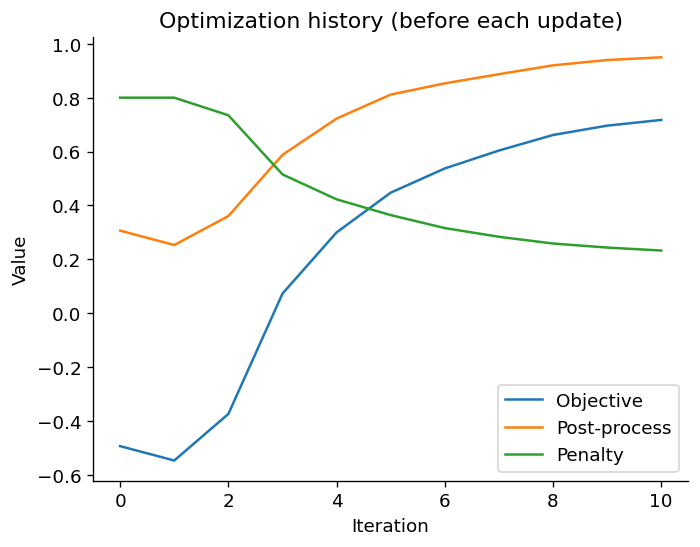

In [10]:
ax = result.plot_optimization()
ax.set_title("Optimization history (before each update)")
ax.figure.savefig(plot_dir / "optimization_history.png", dpi=180, bbox_inches="tight")
plt.show()

### Final modal powers

Report source-normalized output powers and values divided by measured incoming mode power. These are finite-grid modal estimates; the weighted optimization score is distinct from summed output transmission.

In [11]:
final_data = result.simulation_data()
def port_powers(data):
    return np.array([float(bi.utils.sum_abs_squared(bi.utils.get_amps(data,m.name,direction="+",mode_index=0))) for m in outputs])
initial_powers, final_powers = port_powers(initial_data), port_powers(final_data)
incident = float(bi.utils.sum_abs_squared(bi.utils.get_amps(final_data,"input",direction="+",mode_index=0)))
final_score = float(post_process_fn(final_data))
print("Final output powers / measured input:", np.round(final_powers/incident,5))
print("Final post-process score:",round(final_score,6))
assert final_score > initial_score
np.savez(artifacts/"tidy3d_splitter_workflow_verification.npz", initial_powers=initial_powers,
         final_powers=final_powers, measured_input=incident, gradient_error=relative_gradient_error,
         initial_parameters=params0, final_parameters=result.final_params)
display(Markdown(f"**Observed result:** the post-process score improved from **{initial_score:.3f}** "
                 f"to **{final_score:.3f}** after 11 updates. The two gradient backends agreed to "
                 f"**{100*relative_gradient_error:.3f}%** on the perturbed design. "
                 "All reported solves use BeamZ; this is not a cross-solver accuracy claim."))

Final output powers / measured input: [0.28492 0.37238 0.28492]
Final post-process score: 0.948542


**Observed result:** the post-process score improved from **0.306** to **0.949** after 11 updates. The two gradient backends agreed to **0.002%** on the perturbed design. All reported solves use BeamZ; this is not a cross-solver accuracy claim.

### Inspect the optimized device and electric field

Call `Simulation.plot_eps()` and `SimulationResults.plot_field()` directly, as in the reference. These use the final **updated** parameters and continuous permittivity. Source and monitor overlays are disabled for the final permittivity view.

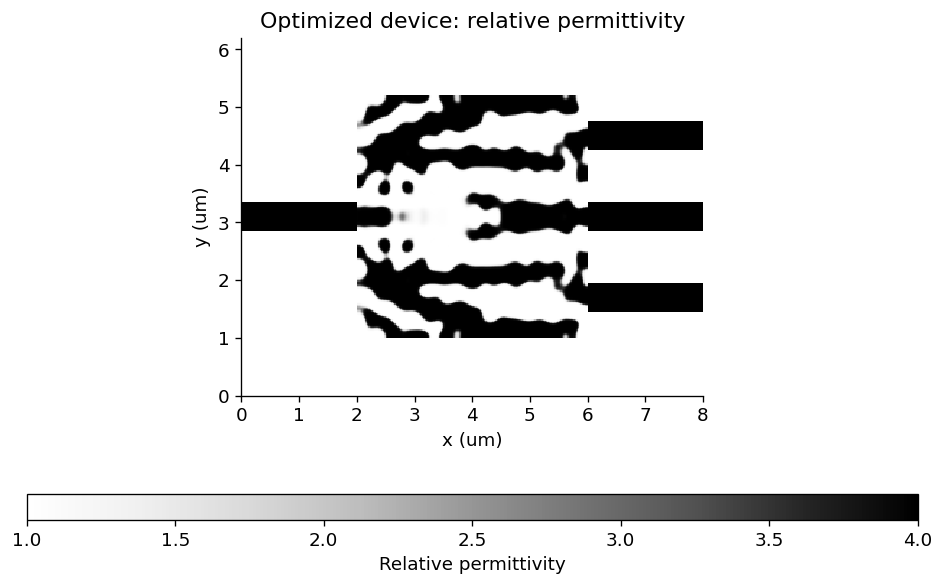

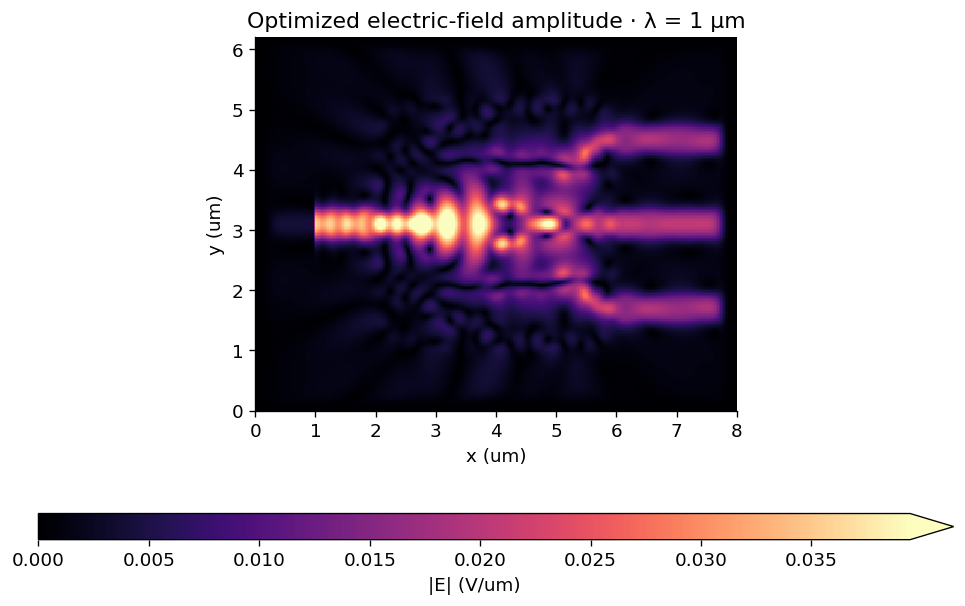

Final parameter mirror mismatch: 0.000526%
Final field mirror mismatch: 0.000813%
No mode, field, gradient, or Adam update was symmetrized.


**Symmetry after 11 updates at 25 nm:** parameter mismatch **0.000526%**, field mismatch **0.000813%**, outer modal-power difference **0.000372%**. No modes, fields, gradients, or Adam updates were symmetrized.

In [12]:
optimized_simulation = result.to_simulation()
fig, ax = optimized_simulation.plot_eps(z=0, source_markers=False, monitor_markers=False,
                                       figsize=(8,5), vmin=1, vmax=4)
ax.set_title("Optimized device: relative permittivity")
fig.savefig(plot_dir / "05_optimized_permittivity.png", dpi=180)
plt.show()

optimized_field_data = optimized_simulation.updated_copy(
    monitors=[*optimized_simulation.monitors, field_monitor]
).run(backend="jax", performance=False)
for monitor in outputs:
    np.testing.assert_allclose(
        optimized_field_data.mode(monitor.name).amps.sel(direction="+",mode_index=0).values,
        final_data[monitor.name].amps.sel(direction="+",mode_index=0).values,
        rtol=5e-5, atol=1e-6)
fig, ax = optimized_field_data.plot_field(field_monitor.name, field_name="E", val="abs",
                                        frequency=frequency, figsize=(8,5), cmap="magma")
ax.set_title("Optimized electric-field amplitude · λ = 1 µm")
fig.savefig(plot_dir / "06_optimized_field_amplitude.png", dpi=180)
plt.show()
np.savez_compressed(plot_dir / "field_data.npz",
    initial_ez=initial_field_data[field_monitor.name].get_dft_component("Ez"),
    optimized_ez=optimized_field_data[field_monitor.name].get_dft_component("Ez"),
    frequency=frequency)

import json
final_ez = optimized_field_data[field_monitor.name].get_dft_component("Ez").reshape(initial_ez.shape)
symmetry_metrics.update(
    final_parameter_mirror_error=mirror_error(result.final_params),
    final_field_mirror_error=mirror_error(final_ez),
    final_outer_power_relative_difference=float(abs(final_powers[0]-final_powers[2]) /
        max((final_powers[0]+final_powers[2])/2, 1e-30)))
(artifacts / "tidy3d_splitter_symmetry.json").write_text(json.dumps(symmetry_metrics, indent=2)+"\n")
print(f"Final parameter mirror mismatch: {100*symmetry_metrics['final_parameter_mirror_error']:.6f}%")
print(f"Final field mirror mismatch: {100*symmetry_metrics['final_field_mirror_error']:.6f}%")
print("No mode, field, gradient, or Adam update was symmetrized.")

display(Markdown(
    f"**Symmetry after 11 updates at {dx/1e-9:g} nm:** parameter mismatch "
    f"**{100*symmetry_metrics['final_parameter_mirror_error']:.6f}%**, field mismatch "
    f"**{100*symmetry_metrics['final_field_mirror_error']:.6f}%**, outer modal-power difference "
    f"**{100*symmetry_metrics['final_outer_power_relative_difference']:.6f}%**. "
    "No modes, fields, gradients, or Adam updates were symmetrized."))


## Next steps

The supported workflow includes differentiable modal callbacks, transformation/penalty sequences, initialization, Adam, history, continuation, and ordinary simulation export. It retains BeamZ objects, metre units, `(y,x)` arrays, and JAX.

Still missing from the broader Tidy3D workflow: 3D gradients, `InverseDesignMulti`, traced shape/material construction through a general simulation `run`, field/flux/far-field objectives, the full xarray interface, and standalone restoration of an executable design object. The current checkpoint is restored against an explicitly supplied optimizer and objective. Changing its backend or optimization definition requires starting a new history from the desired parameters.

## Export the binary layout to GDS

Install the optional layout dependency with `pip install "beamz[gds]"`. Export the final projected density at threshold 0.5 together with the fixed input/output waveguides. The low-index background and the design-region clearing polygons are excluded, leaving only the core mask on layer **0/0**. Coordinates are converted from metres to GDS micrometres by `export_gds`; polygon holes are preserved.

Files go to `results/topology_examples/gds` by default. Set `BEAMZ_GDS_DIR` to choose another destination. GDS stores the planar mask, not a layer thickness or a substrate. These layouts are example simulation results, not fabrication-qualified masks.

This is a 2D model; any thickness used for a 3D rendering is a visualization choice.


In [ ]:
import os
from uuid import uuid4
from beamz.design import export_gds

# Unique cell names allow re-running this cell in the same gdsfactory session.

gds_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
gds_dir = Path(os.environ.get("BEAMZ_GDS_DIR", gds_root / "results/topology_examples/gds")).expanduser()
gds_dir.mkdir(parents=True, exist_ok=True)

binary_layout = result.export_design(threshold=0.5)
# Clearing polygons represent cladding, not material to pattern.
core_layout = Design(
    width=binary_layout.width, height=binary_layout.height, depth=binary_layout.depth,
    background=binary_layout.background,
    structures=[s for s in binary_layout.structures
                if s.material.permittivity > binary_layout.background.permittivity],
)
gds_path = export_gds(core_layout, gds_dir / "tidy3d_inverse_design_splitter.gds",
                      cell_name=f"inverse_design_splitter_{uuid4().hex[:8]}")
print(f"GDS core mask (layer 0/0): {gds_path.resolve()}")
